In [135]:
# Agrego esto para realizar algunas pruebas en otro directorio pero utilizando las funciones definidas por fede...
import os
import sys

# Obtener el path de ejecucion de la notebook
current_dir = os.getcwd()

# Define el nombre del proyecto
root_dir_name = "NuestrasCaras"

# Obtiene el path del proyecto
while not os.path.basename(current_dir) == root_dir_name:
    current_dir = os.path.dirname(current_dir)
    
# Agrega path a librerias
sys.path.append(current_dir)

In [136]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
import numpy as np
import os
from PIL import Image
import cv2

In [137]:
dim_imagenes = 30

In [138]:
# Configuración inicial
data_dir = os.path.join(current_dir, "output") 
nombres = []
imagenes = []

# Cargar imágenes y etiquetas
for archivo in os.listdir(data_dir):
    if archivo.endswith('.jpeg') or archivo.endswith('.jpg'):
        nombre = archivo.split('-')[0]
        ruta_imagen = os.path.join(data_dir, archivo)
        imagen = Image.open(ruta_imagen)
        imagen = np.array(imagen.resize((dim_imagenes, dim_imagenes)))  # Redimensionar imágenes para un tamaño uniforme
        if len(imagen.shape) == 3 and imagen.shape[2] == 3:
            imagen = cv2.cvtColor(imagen, cv2.COLOR_RGB2GRAY)  # Convertir a escala de grises si es necesario
        imagenes.append(imagen.flatten())
        nombres.append(nombre)

imagenes1 = np.array(imagenes)
nombres1 = np.array(nombres)

In [139]:
# Configuración inicial
data_dir = os.path.join(current_dir, "predict/nuevas_caras_cortadas_2")  # Cambia esto a la ruta de tu directorio de imágenes
nombres = []
imagenes = []

# Cargar imágenes y etiquetas
for archivo in os.listdir(data_dir):
    if archivo.endswith('.jpeg') or archivo.endswith('.jpg'):
        nombre = archivo.split('-')[0]
        ruta_imagen = os.path.join(data_dir, archivo)
        imagen = Image.open(ruta_imagen)
        imagen = np.array(imagen.resize((dim_imagenes, dim_imagenes)))  # Redimensionar imágenes para un tamaño uniforme
        if len(imagen.shape) == 3 and imagen.shape[2] == 3:
            imagen = cv2.cvtColor(imagen, cv2.COLOR_RGB2GRAY)  # Convertir a escala de grises si es necesario
        imagenes.append(imagen.flatten())
        nombres.append(nombre)

imagenes2 = np.array(imagenes)
nombres2 = np.array(nombres)

In [140]:
nombres_all = np.concatenate((nombres1, nombres2), axis=0)
imagenes_all = np.concatenate((imagenes1, imagenes2), axis=0)

# solo uso las primeras imagenes
# nombres_all = nombres1
# imagenes_all = imagenes1

In [141]:
# Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(imagenes_all, nombres_all, test_size=0.25, random_state=42, stratify=nombres_all)

In [142]:
# Aplicar PCA
pca = PCA(n_components=60)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)



In [143]:
# Escalar los datos (opcional, si ya has escalado los datos, omite este paso)
from sklearn.preprocessing import StandardScaler, MinMaxScaler
#scaler = StandardScaler()
scaler = MinMaxScaler()
X_train_pca_scaled = scaler.fit_transform(X_train_pca)
X_test_pca_scaled = scaler.transform(X_test_pca)



In [144]:
# Codificar las etiquetas
encoder = LabelEncoder()
y_train_encoded = encoder.fit_transform(y_train)
y_test_encoded = encoder.transform(y_test)
y_train_categorical = to_categorical(y_train_encoded, num_classes=19)
y_test_categorical = to_categorical(y_test_encoded, num_classes=19)



In [145]:
import pandas as pd
pd.Series(nombres_all).unique().shape

(19,)

In [146]:
y_train_categorical.shape

(251, 19)

In [147]:
X_train_pca_scaled[:,3:].shape

(251, 57)

In [162]:
# Establecer la semilla para NumPy para garantizar la reproducibilidad
np.random.seed(42)

# Establecer la semilla para TensorFlow para garantizar la reproducibilidad
tf.random.set_seed(42)

In [163]:
# Definir la red neuronal

entreno_con = X_train_pca_scaled[:,3:]
testeo_con = X_test_pca_scaled[:,3:]

#model = Sequential()
#model.add(Dense(128, input_dim=entreno_con.shape[1], activation='relu'))
#model.add(Dense(64, activation='relu'))
#model.add(Dense(y_train_categorical.shape[1], activation='softmax'))

model = Sequential()
model.add(Input(shape=entreno_con.shape[1:]))  # Definir la entrada del modelo
model.add(Dense(128, activation='sigmoid'))
model.add(Dense(64, activation='sigmoid'))
model.add(Dense(y_train_categorical.shape[1], activation='softmax'))

# Compilar el modelo
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Entrenar el modelo
history = model.fit(entreno_con, y_train_categorical, epochs=500, batch_size=70, validation_split=0.2)

# Evaluar el modelo
loss, accuracy = model.evaluate(testeo_con, y_test_categorical)
print(f'Precisión en el conjunto de prueba: {accuracy * 100:.2f}%')

Epoch 1/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 76ms/step - accuracy: 0.0279 - loss: 3.1140 - val_accuracy: 0.0588 - val_loss: 3.0542
Epoch 2/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.0439 - loss: 3.0250 - val_accuracy: 0.0392 - val_loss: 3.0067
Epoch 3/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.0668 - loss: 2.9740 - val_accuracy: 0.0000e+00 - val_loss: 2.9860
Epoch 4/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.0800 - loss: 2.9448 - val_accuracy: 0.0196 - val_loss: 2.9812
Epoch 5/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.0889 - loss: 2.9279 - val_accuracy: 0.0000e+00 - val_loss: 2.9845
Epoch 6/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.0775 - loss: 2.9181 - val_accuracy: 0.0000e+00 - val_loss: 2.9914
Epoch 7/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.0775 - loss: 2.9130 - val_accuracy: 0.0000e+00 - val_loss: 2.9990
Epoch 8/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.0800 - loss: 2.9109 - val_accuracy: 0.

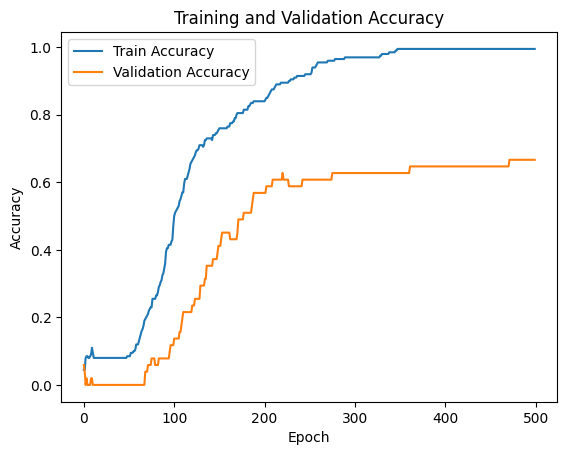

In [164]:
import matplotlib.pyplot as plt

# Obtener la precisión del entrenamiento y del conjunto de prueba del historial
train_accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']

# Crear un gráfico de precisión del entrenamiento y del conjunto de prueba
plt.plot(train_accuracy, label='Train Accuracy')
plt.plot(val_accuracy, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.show()

In [165]:
# Configuración inicial
data_dir = os.path.join(current_dir, "predict/predict_lautaro_cortadas")  # Cambia esto a la ruta de tu directorio de imágenes
nombres = []
imagenes = []

# Cargar imágenes y etiquetas
for archivo in os.listdir(data_dir):
    if archivo.endswith('.jpeg') or archivo.endswith('.jpg'):
        nombre = archivo.split('-')[0]
        ruta_imagen = os.path.join(data_dir, archivo)
        imagen = Image.open(ruta_imagen)
        imagen = np.array(imagen.resize((dim_imagenes, dim_imagenes)))  # Redimensionar imágenes para un tamaño uniforme
        if len(imagen.shape) == 3 and imagen.shape[2] == 3:
            imagen = cv2.cvtColor(imagen, cv2.COLOR_RGB2GRAY)  # Convertir a escala de grises si es necesario
        imagenes.append(imagen.flatten())
        nombres.append(nombre)

new_images = np.array(imagenes)
nombres_lautaro = np.array(nombres)

In [166]:
# 2. Aplicar PCA
new_images_pca = pca.transform(new_images)
new_images_pca_scaled = scaler.transform(new_images_pca)
evaluo_con = new_images_pca_scaled[:,3:]

# 3. Hacer predicciones
predictions = model.predict(evaluo_con)

# Obtener los nombres correspondientes a las clases predichas
predicted_names = encoder.inverse_transform(np.argmax(predictions, axis=1))

# Imprimir las predicciones
for real, pred in zip(nombres_lautaro, predicted_names):
    print(f'La imagen {real} pertenece a: {pred}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
La imagen Lautaro pertenece a: Lautaro
La imagen Lautaro pertenece a: Lisandro
La imagen Lautaro pertenece a: Lautaro
La imagen Lautaro pertenece a: Abel


In [161]:
# 2. Aplicar PCA
imagenes2_pca = pca.transform(imagenes2)
imagenes2_pca_scaled = scaler.transform(imagenes2_pca)
evaluo_con = imagenes2_pca_scaled[:,3:]

# 3. Hacer predicciones
predictions = model.predict(evaluo_con)

# Obtener los nombres correspondientes a las clases predichas
predicted_names = encoder.inverse_transform(np.argmax(predictions, axis=1))

# Imprimir las predicciones
correctas = 0
incorrectas = 0
for real, pred in zip(nombres2, predicted_names):
    print(f'La imagen {real} pertenece a: {pred} ({real==pred})')
    if real==pred:
        correctas = correctas + 1
    else:
        incorrectas = incorrectas + 1
        
print(f"correctas: {(correctas/(correctas+incorrectas))}")
print(f"incorrectas: {(incorrectas/(correctas+incorrectas))}")

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step  
La imagen Abel pertenece a: Abel (True)
La imagen Abel pertenece a: Abel (True)
La imagen Abel pertenece a: Abel (True)
La imagen Abel pertenece a: Abel (True)
La imagen Abel pertenece a: Abel (True)
La imagen Carlos pertenece a: Federico R (False)
La imagen Carlos pertenece a: Carlos (True)
La imagen Carlos pertenece a: Carlos (True)
La imagen Carlos pertenece a: Carlos (True)
La imagen Carlos pertenece a: Paola (False)
La imagen Federico G pertenece a: Abel (False)
La imagen Federico G pertenece a: Federico G (True)
La imagen Federico G pertenece a: Abel (False)
La imagen Federico G pertenece a: Federico G (True)
La imagen Federico G pertenece a: Federico G (True)
La imagen Federico G pertenece a: Federico G (True)
La imagen Federico R pertenece a: Carlos (False)
La imagen Federico R pertenece a: Abel (False)
La imagen Federico R pertenece a: Federico R (True)
La imagen Federico R pertenece a: Federico R (True)
La imagen Federico R pertenece a: 